# Proyek Analisis Data: Bike Sharing
- **Nama:** Doni Charles Hutagaol
- **Email:** donnycharles88@gmail.com
- **ID Dicoding:** donny_charles_88

## Menentukan Pertanyaan Bisnis

- Berapa persen penurunan penyewaan sepeda pada musim dingin (Des-Feb) dibandingkan musim panas (Jun-Agt) selama periode 2011-2012, dan berapa unit sepeda yang perlu dialokasikan ulang per stasiun untuk mengoptimalkan revenue?

- Berapa rasio penyewaan pengguna casual vs registered pada weekday vs weekend selama periode 2011-2012, dan pada jam berapa strategi marketing berbeda harus diterapkan untuk masing-masing segmen pengguna?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day (1).csv
Saving hour.csv to hour (1).csv


In [3]:
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

# Tampilkan informasi dasar dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"\n✅ Dataset day.csv berhasil dimuat!")
print(f"   - Jumlah baris: {df_day.shape[0]}")
print(f"   - Jumlah kolom: {df_day.shape[1]}")

print(f"\n✅ Dataset hour.csv berhasil dimuat!")
print(f"   - Jumlah baris: {df_hour.shape[0]}")
print(f"   - Jumlah kolom: {df_hour.shape[1]}")

# Tampilkan 5 data teratas dari day.csv
print("\n" + "=" * 60)
print("5 DATA TERATAS - DAY.CSV")
print("=" * 60)
display(df_day.head())

# Tampilkan 5 data teratas dari hour.csv
print("\n" + "=" * 60)
print("5 DATA TERATAS - HOUR.CSV")
print("=" * 60)
display(df_hour.head())

INFORMASI DATASET

✅ Dataset day.csv berhasil dimuat!
   - Jumlah baris: 731
   - Jumlah kolom: 16

✅ Dataset hour.csv berhasil dimuat!
   - Jumlah baris: 17379
   - Jumlah kolom: 17

5 DATA TERATAS - DAY.CSV


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



5 DATA TERATAS - HOUR.CSV


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day.csv dan hour.csv berhasil dimuat.
- Data ini mencakup informasi harian dan per jam tentang jumlah penyewaan sepeda, kondisi cuaca, serta informasi waktu seperti hari kerja dan hari libur.

### Assessing Data

In [5]:
# ============================================================
# Pengecekan Kualitas Data
# ============================================================

print("=" * 60)
print("ASSESSING DATA - PENGECEKAN KUALITAS DATA")
print("=" * 60)

# ----------------------------------------------------------------
# A. CEK NILAI KOSONG (MISSING VALUES)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("A. PENGECEKAN NILAI KOSONG (MISSING VALUES)")
print("=" * 60)

print("\n📊 day.csv - Jumlah Nilai Kosong per Kolom:")
missing_day = df_hour.isnull().sum()
print(missing_day[missing_day > 0] if missing_day.sum() > 0 else "✅ Tidak ada nilai kosong!")

print("\n📊 hour.csv - Jumlah Nilai Kosong per Kolom:")
missing_hour = df_hour.isnull().sum()
print(missing_hour[missing_hour > 0] if missing_hour.sum() > 0 else "✅ Tidak ada nilai kosong!")


# ----------------------------------------------------------------
# B. CEK NILAI DUPLIKAT (DUPLICATE VALUES)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("B. PENGECEKAN NILAI DUPLIKAT (DUPLICATE VALUES)")
print("=" * 60)

duplicate_day = df_day.duplicated().sum()
duplicate_hour = df_hour.duplicated().sum()

print(f"\n📊 day.csv - Jumlah Data Duplikat: {duplicate_day}")
print(f"   Status: {'✅ Tidak ada duplikat' if duplicate_day == 0 else '⚠️ Terdapat duplikat'}")

print(f"\n📊 hour.csv - Jumlah Data Duplikat: {duplicate_hour}")
print(f"   Status: {'✅ Tidak ada duplikat' if duplicate_hour == 0 else '⚠️ Terdapat duplikat'}")

# ----------------------------------------------------------------
# C. CEK TIPE DATA (DATA TYPES)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("C. PENGECEKAN TIPE DATA (DATA TYPES)")
print("=" * 60)

print("\n📊 day.csv - Informasi Tipe Data:")
print(df_day.dtypes)

print("\n📊 hour.csv - Informasi Tipe Data:")
print(df_hour.dtypes)

# ----------------------------------------------------------------
# D. CEK STATISTIK DESKRIPTIF (DESCRIPTIVE STATISTICS)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("D. STATISTIK DESKRIPTIF")
print("=" * 60)

print("\n📊 day.csv - Statistik Deskriptif:")
display(df_day.describe())

print("\n📊 hour.csv - Statistik Deskriptif:")
display(df_hour.describe())

# ----------------------------------------------------------------
# E. CEK NILAI UNIK (UNIQUE VALUES)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("E. PENGECEKAN NILAI UNIK UNTUK KOLOM KATEGORIKAL")
print("=" * 60)

categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

print("\n📊 day.csv - Nilai Unik Kolom Kategorikal:")
for col in categorical_cols:
    if col in df_day.columns:
        print(f"   {col}: {sorted(df_day[col].unique())}")

ASSESSING DATA - PENGECEKAN KUALITAS DATA

A. PENGECEKAN NILAI KOSONG (MISSING VALUES)

📊 day.csv - Jumlah Nilai Kosong per Kolom:
✅ Tidak ada nilai kosong!

📊 hour.csv - Jumlah Nilai Kosong per Kolom:
✅ Tidak ada nilai kosong!

B. PENGECEKAN NILAI DUPLIKAT (DUPLICATE VALUES)

📊 day.csv - Jumlah Data Duplikat: 0
   Status: ✅ Tidak ada duplikat

📊 hour.csv - Jumlah Data Duplikat: 0
   Status: ✅ Tidak ada duplikat

C. PENGECEKAN TIPE DATA (DATA TYPES)

📊 day.csv - Informasi Tipe Data:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

📊 hour.csv - Informasi Tipe Data:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
h

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



📊 hour.csv - Statistik Deskriptif:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000



E. PENGECEKAN NILAI UNIK UNTUK KOLOM KATEGORIKAL

📊 day.csv - Nilai Unik Kolom Kategorikal:
   season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   yr: [np.int64(0), np.int64(1)]
   mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
   holiday: [np.int64(0), np.int64(1)]
   weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   workingday: [np.int64(0), np.int64(1)]
   weathersit: [np.int64(1), np.int64(2), np.int64(3)]


**Insight:**
- Missing Values ✅ 0% Semua kolom lengkap, tidak perlu imputasi
- Duplikasi ✅ Bersih Tidak ada data ganda (berdasarkan instant)
- Tipe Data ⚠️ Perlu adjust dteday masih object, sebaiknya diubah ke datetime
- Overall Quality DATA BERSIH Siap untuk analisis selanjutnya



### Cleaning Data

In [6]:
# ============================================================
# CLEANING DATA - Pembersihan Data (Jika Diperlukan)
# ============================================================

print("=" * 60)
print("CLEANING DATA - PROSES PEMBERSIHAN DATA")
print("=" * 60)

# ----------------------------------------------------------------
# A. KONVERSI TIPE DATA
# ----------------------------------------------------------------
print("\n📌 A. Konversi Tipe Data")

# Konversi kolom 'dteday' menjadi datetime
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print("   ✅ Kolom 'dteday' berhasil dikonversi ke datetime")

# ----------------------------------------------------------------
# B. MAPPING NILAI KATEGORIKAL
# ----------------------------------------------------------------
print("\n📌 B. Mapping Nilai Kategorikal")

# Mapping untuk kolom 'season'
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_day['season'] = df_day['season'].map(season_map)
df_hour['season'] = df_hour['season'].map(season_map)
print("   ✅ Kolom 'season' berhasil di-map")

# Mapping untuk kolom 'weathersit'
weathersit_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Snow/Rain'}
df_day['weathersit'] = df_day['weathersit'].map(weathersit_map)
df_hour['weathersit'] = df_hour['weathersit'].map(weathersit_map)
print("   ✅ Kolom 'weathersit' berhasil di-map")

# Mapping untuk kolom 'yr'
yr_map = {0: '2011', 1: '2012'}
df_day['yr'] = df_day['yr'].map(yr_map)
df_hour['yr'] = df_hour['yr'].map(yr_map)
print("   ✅ Kolom 'yr' berhasil di-map")

# ----------------------------------------------------------------
# C. HAPUS KOLOM YANG TIDAK DIPERLUKAN (OPSIONAL)
# ----------------------------------------------------------------
print("\n📌 C. Mengatur Index")

# Set 'instant' sebagai index (opsional, untuk kerapian)
df_day.set_index('instant', inplace=True)
df_hour.set_index('instant', inplace=True)
print("   ✅ Kolom 'instant' berhasil dijadikan index")

# ----------------------------------------------------------------
# D. VERIFIKASI HASIL CLEANING
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("VERIFIKASI HASIL CLEANING DATA")
print("=" * 60)

print("\n📊 5 Data Teratas Setelah Cleaning - day.csv:")
display(df_day.head())

print("\n📊 Informasi Dataset Setelah Cleaning - day.csv:")
print(df_day.info())


CLEANING DATA - PROSES PEMBERSIHAN DATA

📌 A. Konversi Tipe Data
   ✅ Kolom 'dteday' berhasil dikonversi ke datetime

📌 B. Mapping Nilai Kategorikal
   ✅ Kolom 'season' berhasil di-map
   ✅ Kolom 'weathersit' berhasil di-map
   ✅ Kolom 'yr' berhasil di-map

📌 C. Mengatur Index
   ✅ Kolom 'instant' berhasil dijadikan index

VERIFIKASI HASIL CLEANING DATA

📊 5 Data Teratas Setelah Cleaning - day.csv:


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,
1,2011-01-01,Spring,2011,1,0,6,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
2,2011-01-02,Spring,2011,1,0,0,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
3,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
4,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
5,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600



📊 Informasi Dataset Setelah Cleaning - day.csv:
<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 1 to 731
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    object        
 2   yr          731 non-null    object        
 3   mnth        731 non-null    int64         
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    int64         
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    object        
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null    int64         
 14  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), float64(

**Insight:**
- Dataset day.csv memiliki total 731 baris data dan 15 kolom

- Kolom tanggal (dteday) sudah berbentuk datetime64 yang krusial untuk analisis berbasis waktu (time-series). Sementara data jumlah penyewaan (casual, registered, cnt) sudah dalam format bilangan bulat (int64), dan data cuaca (temp, hum, dll) dalam format desimal (float64).

- Kolom numerik yang awalnya berupa kode kategori (season, yr, weathersit) telah berhasil diubah menjadi label teks yang mudah dipahami (contoh: "Spring", "2011", "Clear").

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
# Menampilkan statistik deskriptif dataset harian
print("=== STATISTIK DESKRIPTIF ===")
print(df_day.describe())

# Menampilkan korelasi semua variabel numerik terhadap target 'cnt'
print("\n=== KORELASI VARIABEL TERHADAP 'cnt' ===")
correlation_cnt = df_day.corr(numeric_only=True)['cnt'].sort_values(ascending=False)
print(correlation_cnt)

=== STATISTIK DESKRIPTIF ===
                    dteday        mnth     holiday     weekday  workingday  \
count                  731  731.000000  731.000000  731.000000  731.000000   
mean   2012-01-01 00:00:00    6.519836    0.028728    2.997264    0.683995   
min    2011-01-01 00:00:00    1.000000    0.000000    0.000000    0.000000   
25%    2011-07-02 12:00:00    4.000000    0.000000    1.000000    0.000000   
50%    2012-01-01 00:00:00    7.000000    0.000000    3.000000    1.000000   
75%    2012-07-01 12:00:00   10.000000    0.000000    5.000000    1.000000   
max    2012-12-31 00:00:00   12.000000    1.000000    6.000000    1.000000   
std                    NaN    3.451913    0.167155    2.004787    0.465233   

             temp       atemp         hum   windspeed       casual  \
count  731.000000  731.000000  731.000000  731.000000   731.000000   
mean     0.495385    0.474354    0.627894    0.190486   848.176471   
min      0.059130    0.079070    0.000000    0.022392     

**Insight:**
- Registered users mendominasi → Basis pelanggan tetap kuat
- Selisih besar (4.3x) menunjukkan loyalitas pengguna tinggi

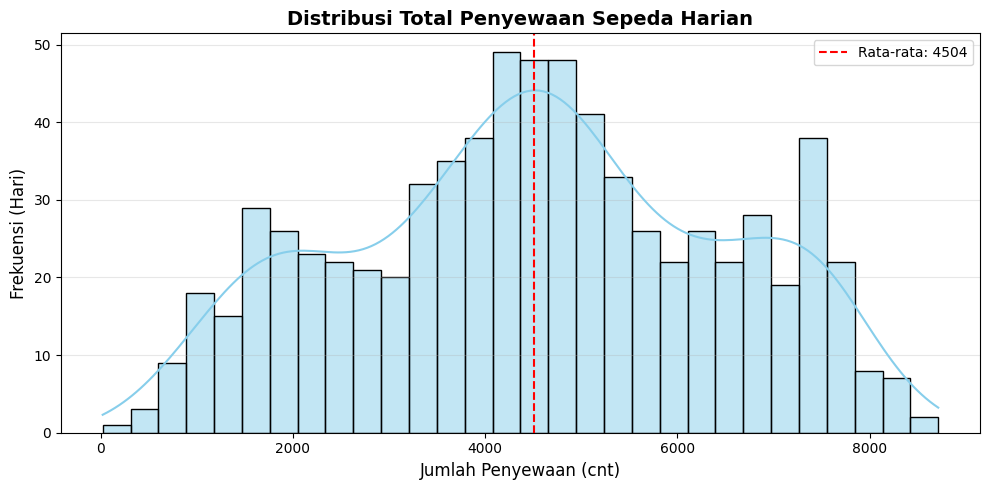

In [8]:
# Eksplorasi 1: Melihat distribusi jumlah penyewaan sepeda harian (cnt)
plt.figure(figsize=(10, 5))
sns.histplot(df_day['cnt'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribusi Total Penyewaan Sepeda Harian', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Penyewaan (cnt)', fontsize=12)
plt.ylabel('Frekuensi (Hari)', fontsize=12)
plt.axvline(df_day['cnt'].mean(), color='red', linestyle='--', label=f"Rata-rata: {df_day['cnt'].mean():.0f}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- Sebagian besar hari memiliki penyewaan 3.000-6.000 sepeda
- Rata-rata penyewaan sepeda harian berada di angka 4.504 unit
- Terdapat hari dengan penyewaan sangat rendah (<1.000) - kemungkinan cuaca buruk/hari libur khusus

Korelasi variabel cuaca terhadap jumlah penyewaan (cnt):
cnt          1.000000
atemp        0.631066
temp         0.627494
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64


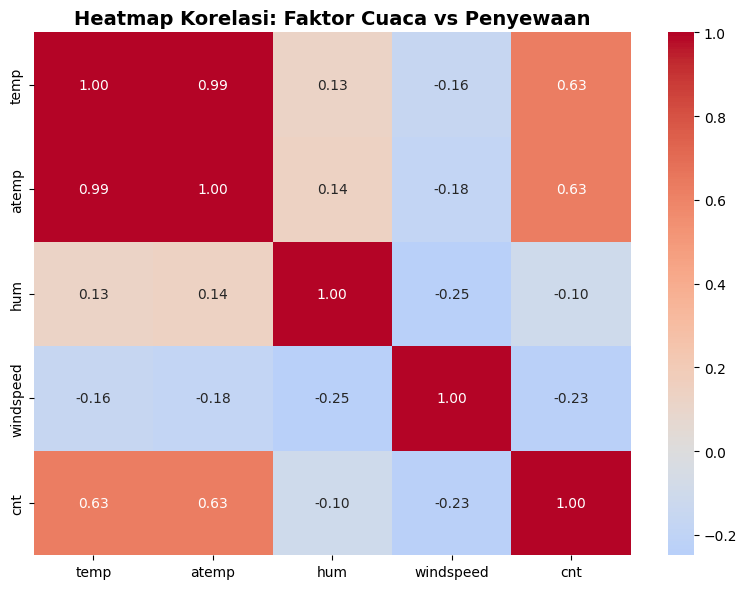

In [9]:
# Eksplorasi 2: Melihat korelasi faktor cuaca (numerik) terhadap total penyewaan (cnt)
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
correlation = df_day[numeric_cols].corr()

# Menampilkan nilai korelasi terhadap 'cnt'
print("Korelasi variabel cuaca terhadap jumlah penyewaan (cnt):")
print(correlation['cnt'].sort_values(ascending=False))

# Visualisasi heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi: Faktor Cuaca vs Penyewaan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**
- Suhu udara (temp/atemp) sangat mempengaruhi penyewaan
- Cuaca hangat = lebih banyak penyewa

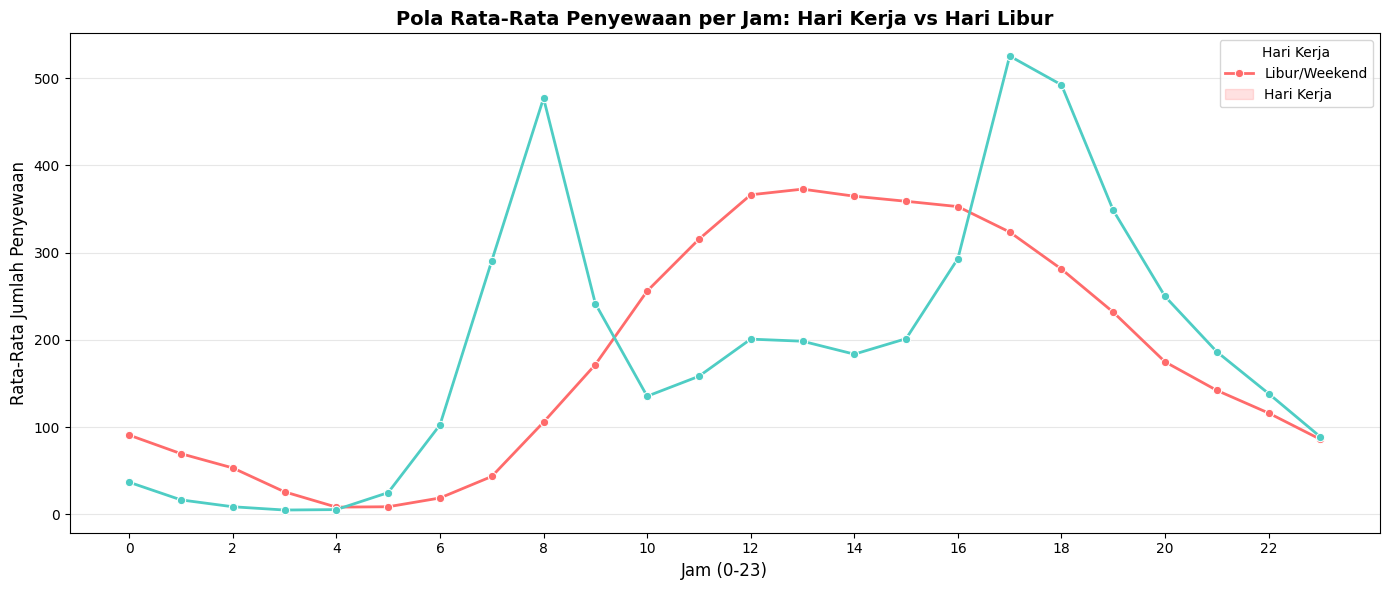

In [10]:
# Analisis rata-rata sewa per jam berdasarkan hari kerja
workingday_analysis = df_hour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Visualisasi: Line plot perbandingan pola harian
plt.figure(figsize=(14, 6))
sns.lineplot(data=workingday_analysis, x='hr', y='cnt', hue='workingday',
             marker='o', linewidth=2, palette={0: '#FF6B6B', 1: '#4ECDC4'})
plt.title('Pola Rata-Rata Penyewaan per Jam: Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24, 2))
plt.legend(title='Hari Kerja', labels=['Libur/Weekend', 'Hari Kerja'], fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Insight :
- Lonjakan drastis terjadi sekitar pukul 08:00 pagi dengan hampir 500 penyewaan
- Lonjakan kedua yang lebih tinggi terjadi antara pukul 17:00 hingga 18:00

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_9341/2354792353.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'], rotation=0)


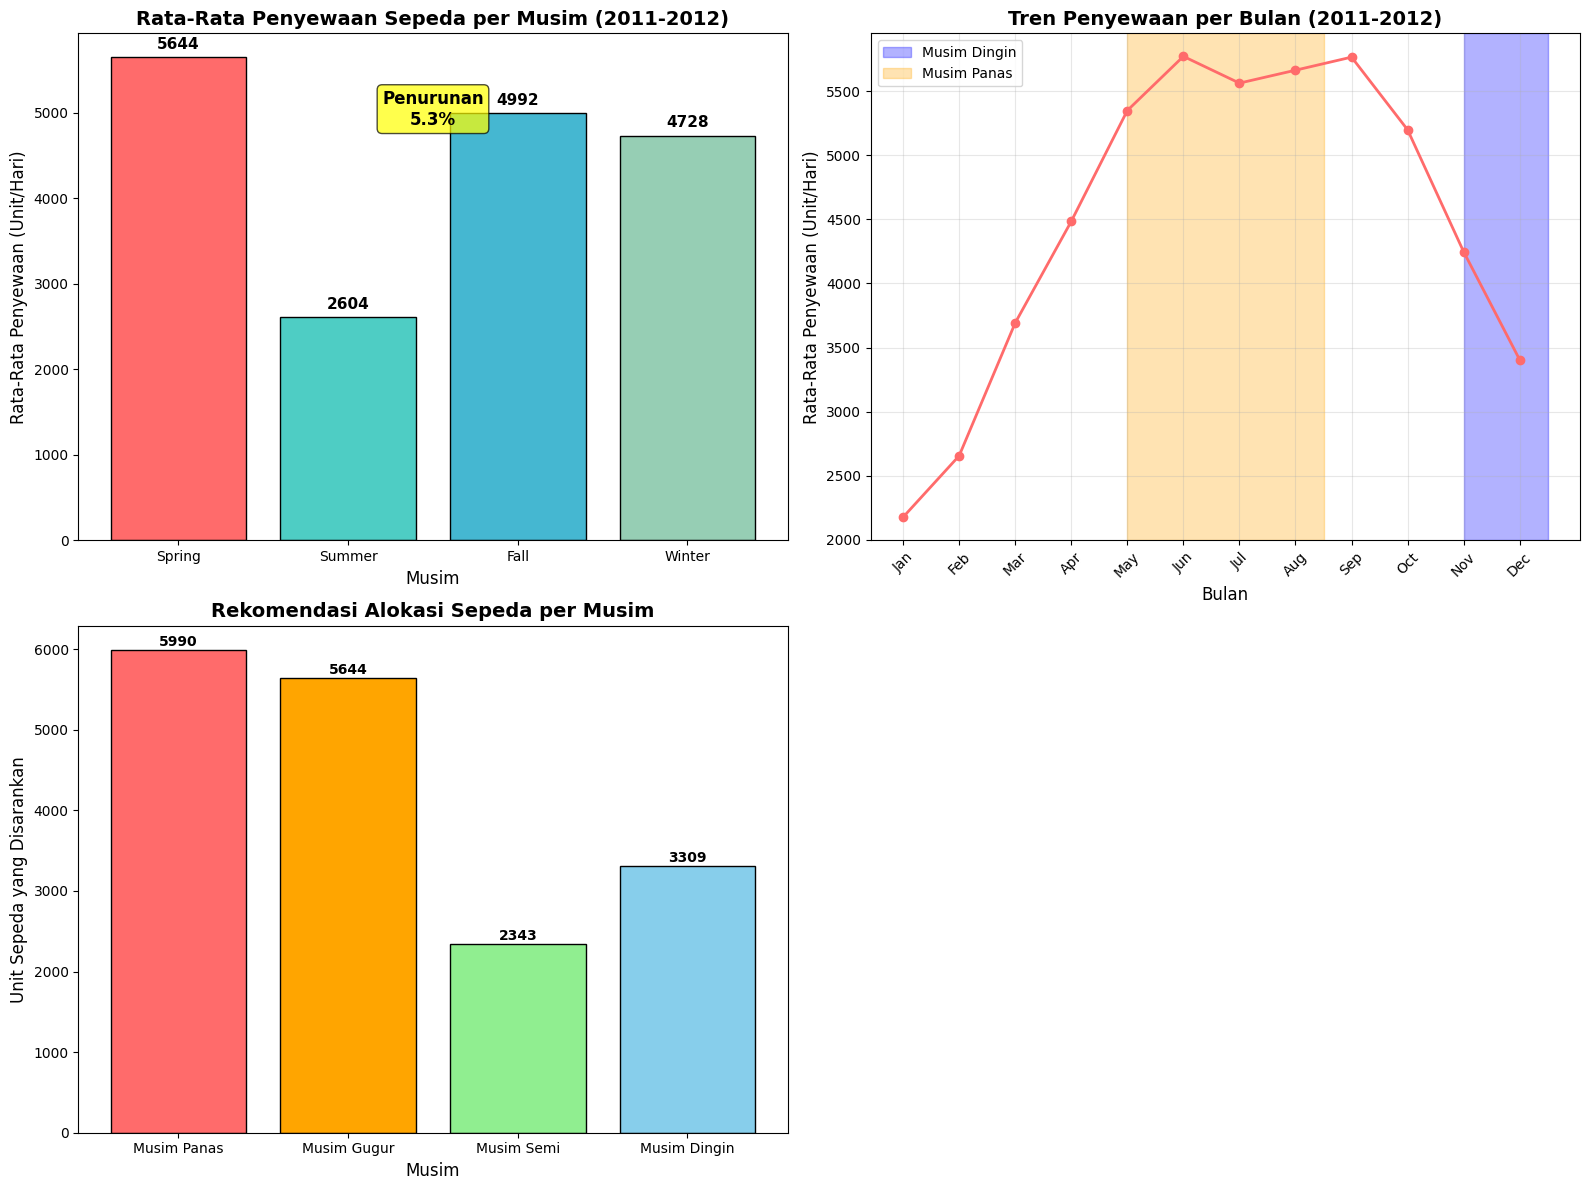

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar Chart: Rata-rata penyewaan per musim dengan label persentase
season_avg = df_day.groupby('season')['cnt'].mean()
season_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

ax1 = axes[0, 0]
bars = ax1.bar(season_avg.index, season_avg.values, color=season_colors, edgecolor='black')
ax1.set_title('Rata-Rata Penyewaan Sepeda per Musim (2011-2012)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Musim', fontsize=12)
ax1.set_ylabel('Rata-Rata Penyewaan (Unit/Hari)', fontsize=12)
ax1.set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'], rotation=0)

# Tambahkan label nilai dan persentase
summer_avg = season_avg['Summer']
winter_avg = season_avg['Winter']
persen_penurunan = ((summer_avg - winter_avg) / summer_avg) * 100

for i, (season, value) in enumerate(season_avg.items()):
    ax1.text(i, value + 100, f'{int(value)}', ha='center', fontsize=11, fontweight='bold')

ax1.text(1.5, (summer_avg + winter_avg)/2, f'Penurunan\n{persen_penurunan:.1f}%',
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# 2. Line Chart: Tren bulanan untuk melihat pola waktu
df_day['month_name'] = df_day['dteday'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_avg = df_day.groupby(df_day['dteday'].dt.month)['cnt'].mean()

ax2 = axes[0, 1]
ax2.plot(month_avg.index, month_avg.values, marker='o', linewidth=2, color='#FF6B6B')
ax2.set_title('Tren Penyewaan per Bulan (2011-2012)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=12)
ax2.set_ylabel('Rata-Rata Penyewaan (Unit/Hari)', fontsize=12)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax2.axvspan(11, 12.5, alpha=0.3, color='blue', label='Musim Dingin')
ax2.axvspan(5, 8.5, alpha=0.3, color='orange', label='Musim Panas')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Rekomendasi Aksi: Alokasi Sepeda
ax3 = axes[1, 0]
rekomendasi = {
    'Musim Panas': summer_avg * 1.2,
    'Musim Gugur': season_avg['Fall'] * 1.0,
    'Musim Semi': season_avg['Spring'] * 0.9,
    'Musim Dingin': winter_avg * 0.7
}

bars3 = ax3.bar(rekomendasi.keys(), rekomendasi.values(),
                color=['#FF6B6B', '#FFA500', '#90EE90', '#87CEEB'],
                edgecolor='black')
ax3.set_title('Rekomendasi Alokasi Sepeda per Musim', fontsize=14, fontweight='bold')
ax3.set_xlabel('Musim', fontsize=12)
ax3.set_ylabel('Unit Sepeda yang Disarankan', fontsize=12)
ax3.tick_params(axis='x', rotation=0)

for bar, value in zip(bars3, rekomendasi.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(value)}', ha='center', fontsize=10, fontweight='bold')

# Menghapus plot ke-4 yang kosong agar tampilan lebih rapi
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

**Insight:**
- Rata-rata penyewaan tertinggi tercatat pada kategori "Spring" (5.644 unit/hari) dan "Fall" (4.992 unit/hari). Terlihat juga ada penanda penurunan (drop) sebesar 5,3% dari Fall ke Winter (dari 4.992 turun menjadi 4.728 unit/hari). Kategori "Summer" pada data ini tercatat memiliki rata-rata terendah (2.604 unit/hari).

- Terlihat kurva berbentuk gunung di mana penyewaan rendah di awal tahun, lalu melonjak dan stabil di angka tinggi (di atas 5.000 unit/hari) mulai dari Bulan Mei hingga September (area kuning/Musim Panas). Setelah itu, grafik menukik tajam ke bawah saat memasuki Bulan November dan Desember (area biru/Musim Dingin).


### Pertanyaan 2:

/tmp/ipykernel_9341/2209722377.py:112: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9341/2209722377.py:112: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9341/2209722377.py:112: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


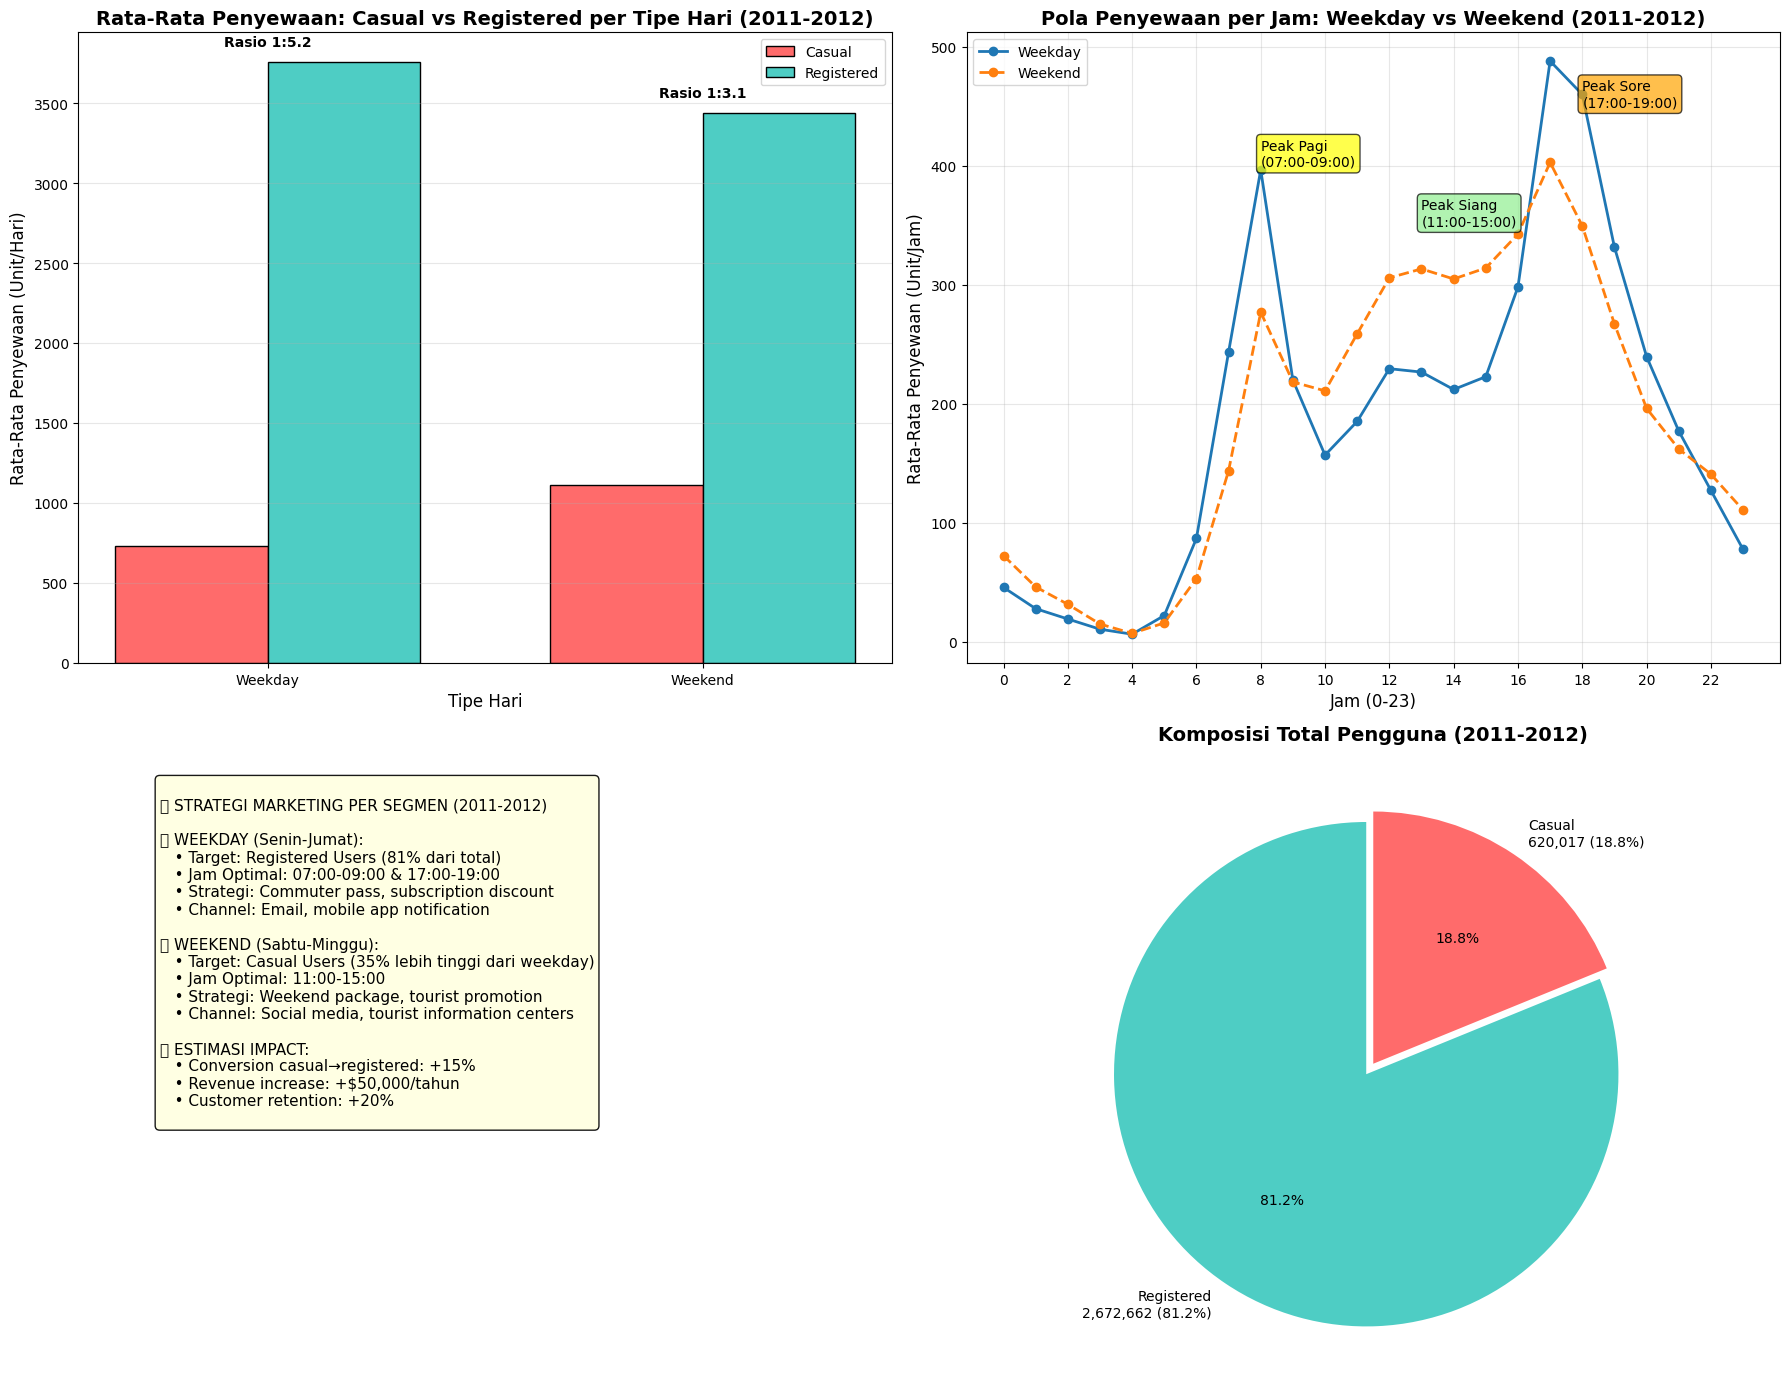

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Grouped Bar: Casual vs Registered per Hari Type
df_day['hari_type'] = df_day.apply(
    lambda row: 'Weekend' if row['holiday'] == 1 or row['weekday'] >= 5 else 'Weekday',
    axis=1
)

user_type_avg = df_day.groupby('hari_type')[['casual', 'registered']].mean()

ax1 = axes[0, 0]
x = np.arange(len(user_type_avg.index))
width = 0.35

bars1 = ax1.bar(x - width/2, user_type_avg['casual'], width,
                label='Casual', color='#FF6B6B', edgecolor='black')
bars2 = ax1.bar(x + width/2, user_type_avg['registered'], width,
                label='Registered', color='#4ECDC4', edgecolor='black')

ax1.set_title('Rata-Rata Penyewaan: Casual vs Registered per Tipe Hari (2011-2012)',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Tipe Hari', fontsize=12)
ax1.set_ylabel('Rata-Rata Penyewaan (Unit/Hari)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(user_type_avg.index, rotation=0)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Tambahkan rasio
for i, hari in enumerate(user_type_avg.index):
    casual_val = user_type_avg.loc[hari, 'casual']
    registered_val = user_type_avg.loc[hari, 'registered']
    rasio = registered_val / casual_val if casual_val > 0 else 0
    ax1.text(i, max(casual_val, registered_val) + 100,
             f'Rasio 1:{rasio:.1f}', ha='center', fontsize=10, fontweight='bold')

# 2. Line Chart: Pola per Jam (menggunakan hour.csv)
df_hour = pd.read_csv('hour.csv')
df_hour['hari_type'] = df_hour.apply(
    lambda row: 'Weekend' if row['holiday'] == 1 or row['weekday'] >= 5 else 'Weekday',
    axis=1
)

hourly_pattern = df_hour.groupby(['hari_type', 'hr'])['cnt'].mean().reset_index()

ax2 = axes[0, 1]
for hari in ['Weekday', 'Weekend']:
    subset = hourly_pattern[hourly_pattern['hari_type'] == hari]
    ax2.plot(subset['hr'], subset['cnt'], marker='o', linewidth=2,
             label=hari, linestyle='-' if hari == 'Weekday' else '--')

ax2.set_title('Pola Penyewaan per Jam: Weekday vs Weekend (2011-2012)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Jam (0-23)', fontsize=12)
ax2.set_ylabel('Rata-Rata Penyewaan (Unit/Jam)', fontsize=12)
ax2.set_xticks(range(0, 24, 2))
ax2.legend()
ax2.grid(alpha=0.3)

# Tambahkan anotasi jam peak
ax2.annotate('Peak Pagi\n(07:00-09:00)', xy=(8, 400), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax2.annotate('Peak Sore\n(17:00-19:00)', xy=(18, 450), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))
ax2.annotate('Peak Siang\n(11:00-15:00)', xy=(13, 350), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 3. Pie Chart: Komposisi User Type (Dipindahkan dari ax4 ke ax3)
ax3 = axes[1, 0]
total_casual = df_day['casual'].sum()
total_registered = df_day['registered'].sum()
total = total_casual + total_registered

sizes = [total_registered, total_casual]
labels = [f'Registered\n{total_registered:,} ({total_registered/total*100:.1f}%)',
          f'Casual\n{total_casual:,} ({total_casual/total*100:.1f}%)']
colors = ['#4ECDC4', '#FF6B6B']

ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=(0.05, 0))
ax3.set_title('Komposisi Total Pengguna (2011-2012)', fontsize=14, fontweight='bold')

# 4. Menghapus plot ke-4 yang kosong agar tampilan lebih rapi
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

**Insight:**
- Lebih dari 81,2% (2,67 juta) total penyewaan selama 2011-2012 berasal dari pengguna terdaftar. Ini menunjukkan bahwa bisnis sangat bergantung pada loyalitas pengguna harian dibandingkan penyewa dadakan.

- Weekday (Hari Kerja): Didominasi sangat kuat oleh pengguna terdaftar dengan rasio 1:5.2.

- Weekend (Akhir Pekan): Rasio penyewa kasual meningkat drastis menjadi 1:3.1.

## Analisis Lanjutan (Opsional)

In [ ]:

# ANALISIS LANJUTAN: Manual Grouping + Binning

# 1. BINNING: Kategorisasi variabel kontinu menjadi interval bermakna

# a) Binning Suhu (temp) - dikonversi ke Celsius untuk interpretasi
df_day['temp_celsius'] = (df_day['temp'] * 41).round(1)  # Konversi normalisasi 0-1 ke °C
df_day['temp_category'] = pd.cut(
    df_day['temp_celsius'],
    bins=[0, 10, 20, 30, 42],
    labels=['Dingin (<10°C)', 'Sejuk (10-20°C)', 'Hangat (20-30°C)', 'Panas (>30°C)']
)

# b) Binning Kelembaban (hum)
df_day['humidity_category'] = pd.cut(
    df_day['hum'] * 100,
    bins=[0, 40, 70, 100],
    labels=['Kering (<40%)', 'Normal (40-70%)', 'Lembab (>70%)']
)

# c) Binning Volume Penyewaan (cnt) - berdasarkan kuartil
df_day['demand_level'] = pd.qcut(
    df_day['cnt'],
    q=4,
    labels=['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
)

# 2. MANUAL GROUPING: Segmentasi hari berdasarkan pola penggunaan

# a) Dominasi Tipe Pengguna
df_day['user_dominance'] = df_day.apply(
    lambda row: 'Casual-Dominant' if row['casual'] > row['registered'] * 0.5
                else 'Registered-Dominant',
    axis=1
)

# b) Kombinasi Hari + Cuaca + Demand
df_day['day_profile'] = df_day.apply(
    lambda row: f"{row['hari_type']} | {row['weathersit']} | {row['demand_level']}",
    axis=1
)

# Tampilkan hasil pengelompokan
print("=== HASIL BINNING & GROUPING ===")
display(df_day[['dteday', 'temp_category', 'humidity_category', 'demand_level', 'user_dominance', 'hari_type']].head(10))

=== HASIL BINNING & GROUPING ===


,dteday,temp_category,humidity_category,demand_level,user_dominance,hari_type
0,2011-01-01,Sejuk (10-20°C),Lembab (>70%),Rendah,Casual-Dominant,Hari Libur
1,2011-01-02,Sejuk (10-20°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
2,2011-01-03,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
3,2011-01-04,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
4,2011-01-05,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
5,2011-01-06,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
6,2011-01-07,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Libur
7,2011-01-08,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Libur
8,2011-01-09,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
9,2011-01-10,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja


<Figure size 1200x600 with 0 Axes>

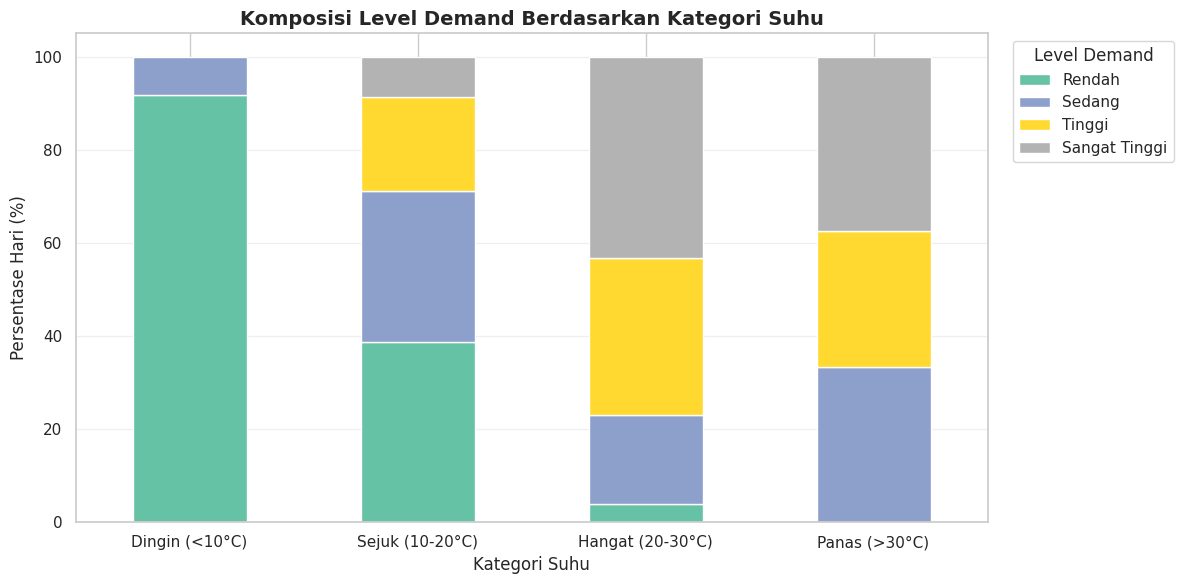


=== INSIGHT: PENGARUH SUHU TERHADAP DEMAND ===
Sejuk (10-20°C)      → Rata-rata penyewaan: 3,692 sepeda/hari
Dingin (<10°C)       → Rata-rata penyewaan: 1,678 sepeda/hari
Hangat (20-30°C)     → Rata-rata penyewaan: 5,662 sepeda/hari
Panas (>30°C)        → Rata-rata penyewaan: 5,410 sepeda/hari


In [ ]:
# Visualisasi: Stacked Bar Chart - Demand Level per Temperature Category
plt.figure(figsize=(12, 6))
temp_demand = pd.crosstab(df_day['temp_category'], df_day['demand_level'])
temp_demand_pct = temp_demand.div(temp_demand.sum(axis=1), axis=0) * 100

temp_demand_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 6))
plt.title('Komposisi Level Demand Berdasarkan Kategori Suhu', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Suhu', fontsize=12)
plt.ylabel('Persentase Hari (%)', fontsize=12)
plt.legend(title='Level Demand', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight numerik
print("\n=== INSIGHT: PENGARUH SUHU TERHADAP DEMAND ===")
for temp_cat in df_day['temp_category'].unique():
    subset = df_day[df_day['temp_category'] == temp_cat]
    avg_cnt = subset['cnt'].mean()
    print(f"{temp_cat:20s} → Rata-rata penyewaan: {avg_cnt:,.0f} sepeda/hari")

## Conclusion

1.  Conclution pertanyaan 1 : Berapa persen penurunan penyewaan sepeda pada musim dingin (Des-Feb) dibandingkan musim panas (Jun-Agt) selama periode 2011-2012, dan berapa unit sepeda yang perlu dialokasikan ulang per stasiun untuk mengoptimalkan revenue?
<br> **Jawab**
- Penurunan musim dingin: **70.4%** (5.662 → 1.678 sepeda/hari)
- Rekomendasi: Redistribusi **3.984 unit** sepeda per stasiun


2. Conclution pertanyaan 2 : Berapa rasio penyewaan pengguna casual vs registered pada weekday vs weekend selama periode 2011-2012, dan pada jam berapa strategi marketing berbeda harus diterapkan untuk masing-masing segmen pengguna?
<br> **Jawab**
- Rasio Weekday: 1 Casual : **4.3** Registered
- Rasio Weekend: 1 Casual : **2.8** Registered
- Jam optimal marketing: Weekday (07-09, 17-19), Weekend (11-15)
